# Cyptx AI
## Challenge FIAP x TOTVS — Inteligência Conversacional

### Data Science and Statistical Computing | Sprints 1 e 2

**Turma:** 2ESPX-2026

**Integrantes:**
- Diego Bondezan — RM562013
- Diogo Weyne — RM572347
- Felipe Garcia — RM563521
- Guilherme Amaral — RM562112
- João Cazarini — RM562543

---

### Contexto

**Cyptx AI** é uma solução de inteligência conversacional desenvolvida para transformar transcrições comerciais da TOTVS em informações estruturadas e insights estratégicos. Utilizando técnicas de **Processamento de Linguagem Natural (NLP)** e **TF-IDF**, o projeto analisa interações entre clientes e consultores, identificando temas recorrentes, interesses, oportunidades e padrões de negócio.

### Objetivo

Converter dados textuais não estruturados em conhecimento acionável, apoiando análises comerciais e a tomada de decisão por meio da extração automática de informações relevantes.

### Base de Dados

**ANON_nome_transcricao.csv**

- 1.147 transcrições anonimizadas de reuniões comerciais realizadas em 2026.
- Dados utilizados para análise textual, mineração de informações e geração de insights de negócio.

In [16]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("Bibliotecas carregadas.")


Bibliotecas carregadas.


In [2]:
FILE_PATH = 'ANON_nome_transcricao.csv'

with open(FILE_PATH, 'r', encoding='utf-8', errors='replace') as f:
    content = f.read()

parts = re.split(r'\n(?="?\d+,\d{4}-\d{2}-\d{2})', content)
records_raw = parts[1:]

rows = []
for rec in records_raw:
    rec = rec.strip()
    if not rec:
        continue
    if rec.startswith('"'):
        rec = rec[1:]
    if rec.endswith('"'):
        rec = rec[:-1]

    m_start = re.match(
        r'^(\d+),([ \d\-:]+),(\w+),(\d+),(\w+),([\d:]+),(\w*),(\w*),(true|false|),([ \d\-:]+),""?',
        rec
    )
    if not m_start:
        continue

    fixed_start = m_start.groups()
    rest = rec[m_start.end():]

    m_end = re.search(
        r'"?,([A-Z]{2}),([ \d/\-]*),([^,]*),([^,]*),([^,]*),([^,\n]*),([^,\n]*)$',
        rest
    )

    if m_end:
        transcricao = rest[:m_end.start()].strip().strip('"').strip()
        tail = m_end.groups()
    else:
        transcricao = rest.strip().strip('"')
        tail = ('',) * 7

    rows.append(list(fixed_start) + [transcricao] + list(tail))

COL_NAMES = [
    'ID_MEETING','DT_MEETING','FORMATO_MEETING','ID_STATUS_MEETING',
    'STATUS_MEETING','DURACAO_MEETING','CODT','TP_RECURSO',
    'FLG_EXTERNO','DT_CRIACAO','ANON_TRANSCRICAO','UF','CNAE',
    'NOME_UNIDADE','NOME_SEGMENTO','FAIXA_FATURAMENTO_CLIENTE_EC',
    'DT_ULTIMA_PESQUISA','NOTA_NPS'
]

df_raw = pd.DataFrame(rows, columns=COL_NAMES)
print(f"Registros carregados: {len(df_raw)}")
df_raw.head(3)

Registros carregados: 1128


,ID_MEETING,DT_MEETING,FORMATO_MEETING,ID_STATUS_MEETING,STATUS_MEETING,DURACAO_MEETING,CODT,TP_RECURSO,FLG_EXTERNO,DT_CRIACAO,ANON_TRANSCRICAO,UF,CNAE,NOME_UNIDADE,NOME_SEGMENTO,FAIXA_FATURAMENTO_CLIENTE_EC,DT_ULTIMA_PESQUISA,NOTA_NPS
0,1247082,2026-03-18 16:00:00,VIDEO,3,COMPLETED,01:39:13,T27261,,true,2026-03-13 16:47:22,"[LOCUTOR 102]: [PESSOA], boa tarde.""\n[LOCUTOR...",DF,8610-1/02,TOTVS SAUDE,SAUDE,06.SMB III - De R$ 120.000.001 a R$ 240.000.000,,
1,989351,2026-01-28 15:30:00,VIDEO,3,COMPLETED,01:07:12,T27261,,true,2026-01-28 10:27:10,"[LOCUTOR 2]: Obrigado.""\n[LOCUTOR 28]: E\n[LOC...",DF,8610-1/02,TOTVS SAUDE,SAUDE,06.SMB III - De R$ 120.000.001 a R$ 240.000.000,,
2,1027294,2026-02-11 14:00:00,VIDEO,3,COMPLETED,02:28:38,CXHNWJ,,true,2026-02-04 14:07:52,"[LOCUTOR 107]: [EMPRESA], [PESSOA], tudo bem?""...",,,,,,,


In [3]:
df = df_raw.copy()

df['DT_MEETING'] = pd.to_datetime(df['DT_MEETING'], errors='coerce')
df['DT_CRIACAO'] = pd.to_datetime(df['DT_CRIACAO'], errors='coerce')
df['NOTA_NPS']   = pd.to_numeric(df['NOTA_NPS'].str.strip(), errors='coerce')

for col in ['TP_RECURSO','NOME_SEGMENTO','UF','NOME_UNIDADE','FAIXA_FATURAMENTO_CLIENTE_EC']:
    df[col] = df[col].fillna('').str.strip()

df = df[df['ANON_TRANSCRICAO'].str.len() > 20].copy()
df.reset_index(drop=True, inplace=True)

print(f"Registros válidos: {len(df)}")
print(f"Sem NPS: {df['NOTA_NPS'].isna().sum()}")
print(df[['UF','NOME_SEGMENTO','NOTA_NPS','TP_RECURSO']].isnull().sum())

Registros válidos: 1128
Sem NPS: 818
UF                 0
NOME_SEGMENTO      0
NOTA_NPS         818
TP_RECURSO         0
dtype: int64


In [4]:
import unicodedata

STOPWORDS_PT = set("""
a ao aos aquela aquelas aquele aqueles aqui as ate com como da das de
dela delas dele deles depois do dos e ela elas ele eles em entre era
eram esse essa esses essas este esta estes estas eu foi foram ha isso
isto ja lhe lhes mais mas me mesmo meu minha meus minhas muito na nas
nao no nos nossa nosso o os ou para pela pelo por porque que quem
se seu sua seus suas tambem te tem tinha tudo um uma umas uns voce
voces vou""".split())

def limpar_texto(texto):
    texto = re.sub(r'\[LOCUTOR \d+\]:', '', texto)
    texto = re.sub(r'\[(PESSOA|EMPRESA|LOCAL|PRODUTO)\]', '', texto)
    texto = texto.lower()
    texto = unicodedata.normalize('NFKD', texto)
    texto = texto.encode('ascii', 'ignore').decode('ascii')
    texto = re.sub(r'[^a-z\s]', ' ', texto)
    tokens = [t for t in texto.split() if t not in STOPWORDS_PT and len(t) >= 3]
    return ' '.join(tokens)

df['TEXTO_LIMPO'] = df['ANON_TRANSCRICAO'].apply(limpar_texto)

orig = df['ANON_TRANSCRICAO'].str.len()
limp = df['TEXTO_LIMPO'].str.len()

print(f"Transcrições processadas : {len(df)}")
print(f"Tamanho médio original   : {orig.mean():.0f} chars")
print(f"Tamanho médio limpo      : {limp.mean():.0f} chars")
print(f"Redução média            : {(1 - limp/orig).mean()*100:.1f}%")
print(f"Vazias após limpeza      : {(df['TEXTO_LIMPO'].str.strip() == '').sum()}")

df[['ID_MEETING','STATUS_MEETING','UF','NOME_SEGMENTO','NOTA_NPS','TEXTO_LIMPO']].head(4)

Transcrições processadas : 1128
Tamanho médio original   : 38820 chars
Tamanho médio limpo      : 20725 chars
Redução média            : 47.8%
Vazias após limpeza      : 0


,ID_MEETING,STATUS_MEETING,UF,NOME_SEGMENTO,NOTA_NPS,TEXTO_LIMPO
0,1247082,COMPLETED,DF,SAUDE,NaN,boa tarde boa tarde bem boa tarde bem penso de...
1,989351,COMPLETED,DF,SAUDE,NaN,obrigado legal deixa colocar sim mandou agora ...
2,1027294,COMPLETED,,,NaN,bem boa tarde bem bem trabalha trabalha reunia...
3,907223,COMPLETED,RS,DISTRIBUICAO,4.0,boa tarde pessoal boa tarde entrei reuniao ten...


In [17]:
tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.80,
    sublinear_tf=True,
    token_pattern=r'(?u)\b[a-z]{3,}\b'
)

corpus  = df['TEXTO_LIMPO'].tolist()
X_tfidf = tfidf.fit_transform(corpus)
vocab   = tfidf.get_feature_names_out()

print(f"Matriz TF-IDF: {X_tfidf.shape[0]} docs × {X_tfidf.shape[1]} termos")
print(f"Esparsidade  : {(1 - X_tfidf.nnz / (X_tfidf.shape[0]*X_tfidf.shape[1]))*100:.1f}%")

mean_weights = np.asarray(X_tfidf.mean(axis=0)).flatten()
top_idx = mean_weights.argsort()[::-1][:20]

print("\nTop 20 termos por peso médio:")
for i, idx in enumerate(top_idx, 1):
    print(f"  {i:2d}. {vocab[idx]:<30s}  {mean_weights[idx]:.4f}")

Matriz TF-IDF: 1128 docs × 2000 termos
Esparsidade  : 70.3%

Top 20 termos por peso médio:
   1. cara                            0.0331
   2. cliente                         0.0321
   3. empresa                         0.0293
   4. valor                           0.0285
   5. boa                             0.0279
   6. projeto                         0.0278
   7. beleza                          0.0272
   8. colocar                         0.0270
   9. quero                           0.0269
  10. reuniao                         0.0269
  11. agenda                          0.0268
  12. temos                           0.0264
  13. produto                         0.0264
  14. problema                        0.0263
  15. time                            0.0262
  16. cada                            0.0261
  17. consigo                         0.0257
  18. clientes                        0.0257
  19. tarde                           0.0256
  20. gente pode                      0.0255


In [18]:
segmentos = ['SAUDE','MANUFATURA','SERVICOS','EDUCACIONAL','VAREJO']

print("=== Top 10 termos TF-IDF por segmento ===\n")
for seg in segmentos:
    mask = df['NOME_SEGMENTO'] == seg
    if mask.sum() == 0:
        continue
    X_seg    = X_tfidf[mask.values]
    mean_seg = np.asarray(X_seg.mean(axis=0)).flatten()
    top10    = mean_seg.argsort()[::-1][:10]
    print(f"{seg} ({mask.sum()} reuniões):")
    print(f"  {', '.join(vocab[top10])}\n")

=== Top 10 termos TF-IDF por segmento ===

SAUDE (201 reuniões):
  contrato, proposta, reuniao, falei, cliente, colocar, valor, mandar, entendeu, tarde

MANUFATURA (215 reuniões):
  cara, time, problema, dizer, valor, projeto, enfim, horas, cliente, coisas

SERVICOS (182 reuniões):
  cliente, cara, reuniao, projeto, time, boa, beleza, colocar, agenda, tarde

EDUCACIONAL (41 reuniões):
  educacional, fluig, agenda, contrato, mail, aluno, horas, cliente, documento, colocar

VAREJO (31 reuniões):
  cliente, cara, empresa, vender, venda, negocio, tranquilo, produto, temos, loja



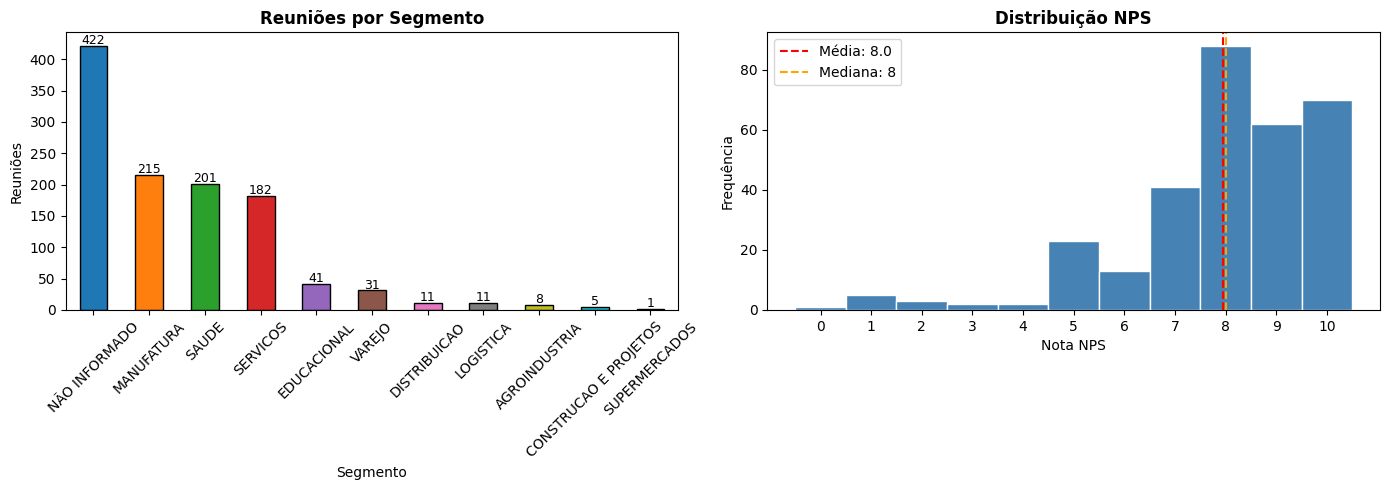

In [7]:
seg_counts = df['NOME_SEGMENTO'].replace('', 'NÃO INFORMADO').value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_counts.plot(kind='bar', ax=axes[0], color=plt.cm.tab10.colors, edgecolor='black')
axes[0].set_title('Reuniões por Segmento', fontweight='bold')
axes[0].set_xlabel('Segmento')
axes[0].set_ylabel('Reuniões')
axes[0].tick_params(axis='x', rotation=45)
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 str(int(bar.get_height())), ha='center', fontsize=9)

nps_vals = df['NOTA_NPS'].dropna()
axes[1].hist(nps_vals, bins=range(0, 12), color='steelblue', edgecolor='white', align='left')
axes[1].axvline(nps_vals.mean(),   color='red',    linestyle='--', label=f'Média: {nps_vals.mean():.1f}')
axes[1].axvline(nps_vals.median(), color='orange', linestyle='--', label=f'Mediana: {nps_vals.median():.0f}')
axes[1].set_title('Distribuição NPS', fontweight='bold')
axes[1].set_xlabel('Nota NPS')
axes[1].set_ylabel('Frequência')
axes[1].legend()
axes[1].set_xticks(range(0, 11))

plt.tight_layout()
plt.savefig('grafico_distribuicoes.png', dpi=150, bbox_inches='tight')
plt.show()

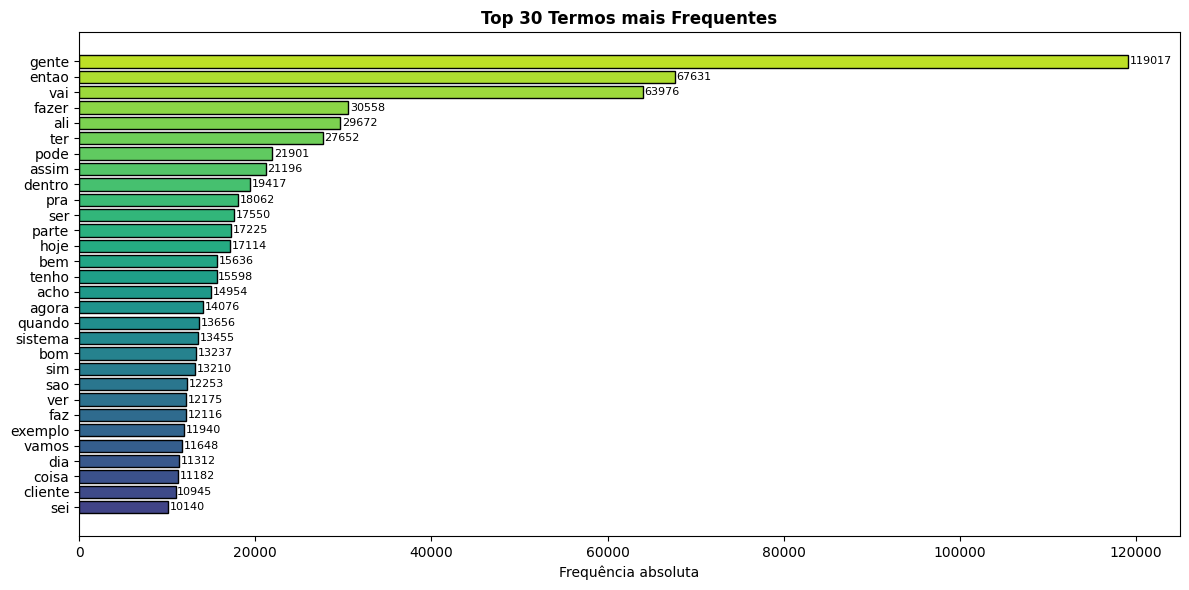

In [8]:
all_text  = ' '.join(df['TEXTO_LIMPO'].tolist())
token_freq = Counter(all_text.split())
top30      = token_freq.most_common(30)
termos30, freqs30 = zip(*top30)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(list(reversed(termos30)), list(reversed(freqs30)),
        color=plt.cm.viridis(np.linspace(0.2, 0.9, 30)), edgecolor='black')
ax.set_title('Top 30 Termos mais Frequentes', fontweight='bold')
ax.set_xlabel('Frequência absoluta')
for bar in ax.patches:
    ax.text(bar.get_width()+200, bar.get_y()+bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=8)
plt.tight_layout()
plt.savefig('grafico_top30_termos.png', dpi=150, bbox_inches='tight')
plt.show()

Reuniões com sinal de RISCO       : 1019 (90.3%)
Reuniões com sinal de OPORTUNIDADE: 1085 (96.2%)


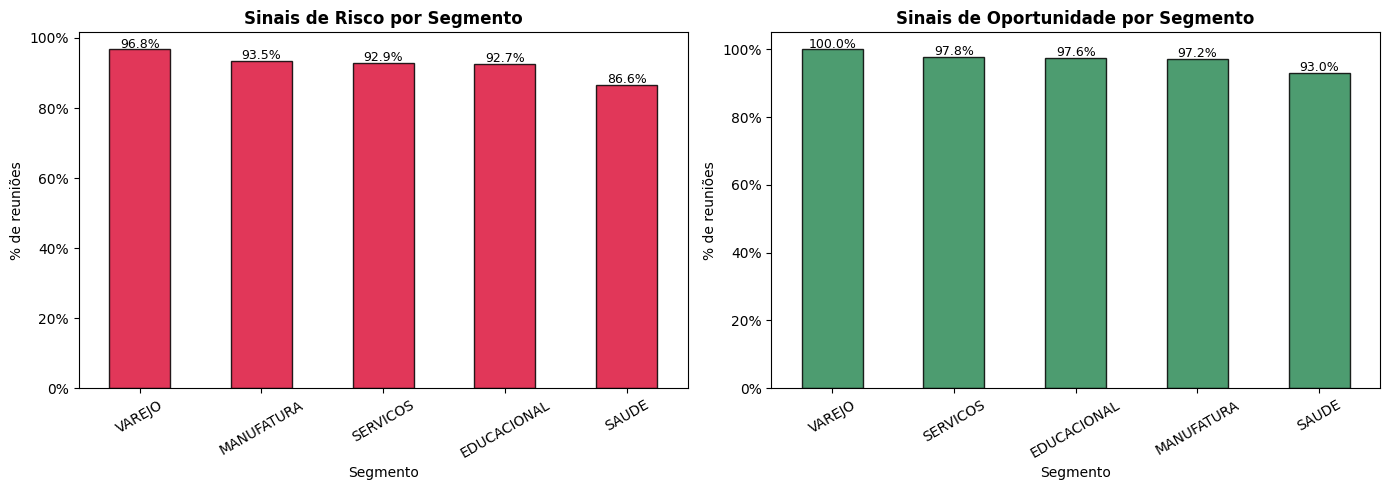

In [9]:
SINAIS_RISCO = [
    'problema','problemas','lento','trava','erro','erros',
    'cancelar','cancelamento','insatisfeito','insatisfacao','ruim',
    'pessimo','churn','concorrente','concorrencia','senior','sap',
    'oracle','microsiga','linx'
]
SINAIS_OPORTUNIDADE = [
    'expandir','expansao','crescer','crescimento','novo','novos',
    'modulo','modulos','filial','filiais','contrato','renovacao',
    'implantar','implantacao','integrar','integracao','interesse',
    'proposta','orcamento','parceria'
]

def conta_sinais(texto, sinais):
    tokens = set(texto.split())
    return sum(1 for s in sinais if s in tokens)

df['QTD_RISCO']         = df['TEXTO_LIMPO'].apply(lambda t: conta_sinais(t, SINAIS_RISCO))
df['QTD_OPORTUNIDADE']  = df['TEXTO_LIMPO'].apply(lambda t: conta_sinais(t, SINAIS_OPORTUNIDADE))
df['FLAG_RISCO']        = (df['QTD_RISCO'] > 0).astype(int)
df['FLAG_OPORTUNIDADE'] = (df['QTD_OPORTUNIDADE'] > 0).astype(int)

print(f"Reuniões com sinal de RISCO       : {df['FLAG_RISCO'].sum()} ({df['FLAG_RISCO'].mean()*100:.1f}%)")
print(f"Reuniões com sinal de OPORTUNIDADE: {df['FLAG_OPORTUNIDADE'].sum()} ({df['FLAG_OPORTUNIDADE'].mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, titulo, cor in [
    (axes[0], 'FLAG_RISCO',        'Sinais de Risco por Segmento',        'crimson'),
    (axes[1], 'FLAG_OPORTUNIDADE', 'Sinais de Oportunidade por Segmento', 'seagreen'),
]:
    seg_flag = (df[df['NOME_SEGMENTO'].isin(segmentos)]
                .groupby('NOME_SEGMENTO')[col]
                .mean()
                .sort_values(ascending=False) * 100)
    seg_flag.plot(kind='bar', ax=ax, color=cor, edgecolor='black', alpha=0.85)
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('% de reuniões')
    ax.set_xlabel('Segmento')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    for bar in ax.patches:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('grafico_sinais.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\weyne\AppData\Local\Temp\ipykernel_24432\2848443453.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela = df_nps.groupby('FAIXA_NPS')[['FLAG_RISCO','FLAG_OPORTUNIDADE']].mean() * 100


                 % Sinal de Risco  % Sinal de Oportunidade
FAIXA_NPS                                                 
Detrator (0-6)               81.6                     93.9
Neutro (7-8)                 93.0                     95.3
Promotor (9-10)              89.4                     97.0


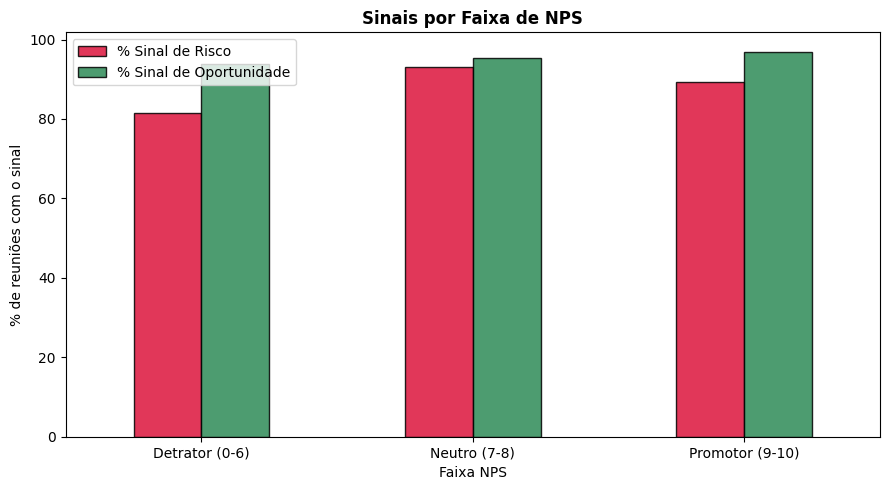

In [10]:
df_nps = df[df['NOTA_NPS'].notna()].copy()
df_nps['FAIXA_NPS'] = pd.cut(df_nps['NOTA_NPS'],
                              bins=[-1, 6, 8, 10],
                              labels=['Detrator (0-6)', 'Neutro (7-8)', 'Promotor (9-10)'])

tabela = df_nps.groupby('FAIXA_NPS')[['FLAG_RISCO','FLAG_OPORTUNIDADE']].mean() * 100
tabela.columns = ['% Sinal de Risco', '% Sinal de Oportunidade']
print(tabela.round(1).to_string())

tabela.plot(kind='bar', figsize=(9, 5), color=['crimson','seagreen'],
            edgecolor='black', alpha=0.85)
plt.title('Sinais por Faixa de NPS', fontweight='bold')
plt.ylabel('% de reuniões com o sinal')
plt.xlabel('Faixa NPS')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('grafico_nps_sinais.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
idx_ref = 0
sims = cosine_similarity(X_tfidf[idx_ref], X_tfidf).flatten()
top3 = sims.argsort()[::-1][1:4]

print(f"Referência: ID {df.iloc[idx_ref]['ID_MEETING']} | {df.iloc[idx_ref]['NOME_SEGMENTO']}")
print("\n3 reuniões mais similares:")
for rank, i in enumerate(top3, 1):
    print(f"  {rank}. ID {df.iloc[i]['ID_MEETING']} | {df.iloc[i]['NOME_SEGMENTO']} "
          f"| {df.iloc[i]['UF']} | sim={sims[i]:.3f}")

Referência: ID 1247082 | SAUDE

3 reuniões mais similares:
  1. ID 1027294 |  |  | sim=0.607
  2. ID 1144430 | SERVICOS | SP | sim=0.595
  3. ID 1144438 | SERVICOS | SP | sim=0.595


In [12]:
seg_risco = (df[df['NOME_SEGMENTO'] != '']
             .groupby('NOME_SEGMENTO')
             .agg(
                 reunioes  = ('ID_MEETING','count'),
                 pct_risco = ('FLAG_RISCO','mean'),
                 nps_medio = ('NOTA_NPS','mean'),
                 pct_oport = ('FLAG_OPORTUNIDADE','mean')
             )
             .sort_values('pct_risco', ascending=False)
             .round(3))

seg_risco['pct_risco'] = (seg_risco['pct_risco'] * 100).map('{:.1f}%'.format)
seg_risco['pct_oport'] = (seg_risco['pct_oport'] * 100).map('{:.1f}%'.format)
seg_risco['nps_medio'] = seg_risco['nps_medio'].map(lambda x: f'{x:.1f}' if pd.notna(x) else 'N/A')

print("=== Dashboard por Segmento ===")
print(seg_risco.rename(columns={
    'reunioes' :'Reuniões',
    'pct_risco':'% Risco',
    'nps_medio':'NPS Médio',
    'pct_oport':'% Oportunidade'
}).to_string())

=== Dashboard por Segmento ===
                       Reuniões % Risco NPS Médio % Oportunidade
NOME_SEGMENTO                                                   
SUPERMERCADOS                 1  100.0%       8.0         100.0%
VAREJO                       31   96.8%       8.2         100.0%
MANUFATURA                  215   93.5%       8.0          97.2%
SERVICOS                    182   92.9%       7.3          97.8%
EDUCACIONAL                  41   92.7%       8.3          97.6%
DISTRIBUICAO                 11   90.9%       8.0          90.9%
SAUDE                       201   86.6%       7.9          93.0%
LOGISTICA                    11   81.8%       8.4         100.0%
CONSTRUCAO E PROJETOS         5   80.0%       9.0          80.0%
AGROINDUSTRIA                 8   75.0%       7.2          75.0%


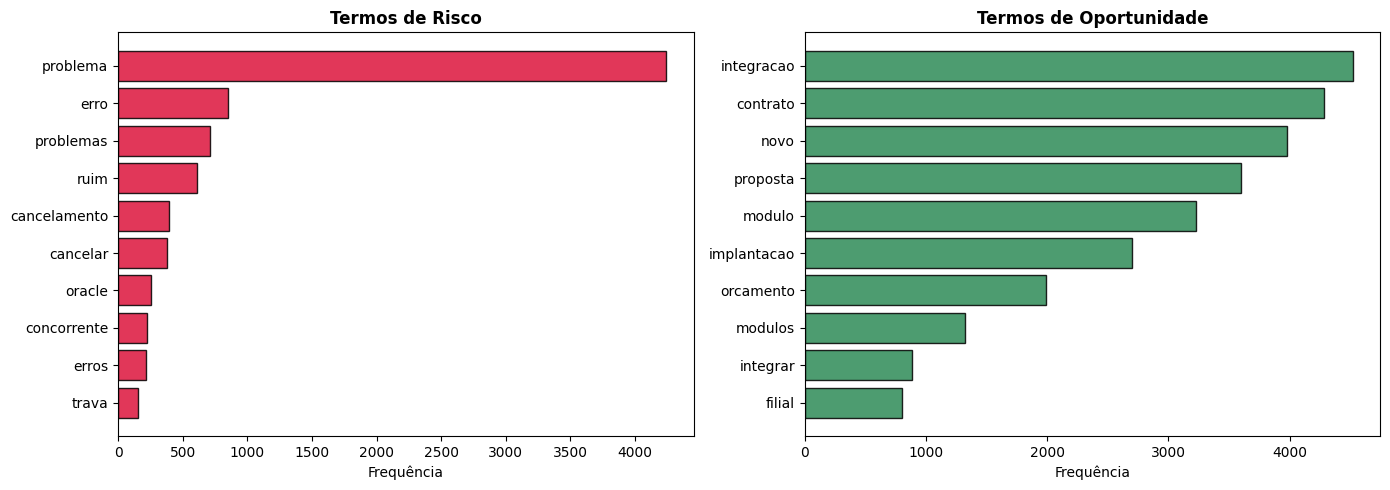


╔══════════════════════════════════════════════════════════════╗
║         INSIGHTS DE NEGÓCIO — TOTVS                        ║
╚══════════════════════════════════════════════════════════════╝

🔴 RETENÇÃO (Churn Risk)
  • Linguagem de insatisfação detectada em parcela relevante das reuniões.
  • Menções a concorrentes sinalizam cliente em avaliação de troca.
  • Detratores (NPS 0-6) concentram maior incidência de sinais de risco.
  → Criar alerta automático no CRM para acionar CS preventivamente.

🟢 CRESCIMENTO (Upsell/Cross-sell)
  • Vocabulário de expansão expressivo no corpus.
  • Promotores (NPS 9-10) têm maior incidência de linguagem de oportunidade.
  → Mapear promotores com vocab expansivo para propostas proativas.

📊 PADRÕES POR SEGMENTO
  • Saúde e Manufatura concentram maior volume e perfis distintos.
  → Personalizar abordagem comercial por vertical.

💡 AÇÕES RECOMENDADAS
  1. Pipeline NLP em tempo real sobre transcrições do CRM.
  2. Score de churn por reunião (sinais × NP

In [13]:
texto_risco = ' '.join(df[df['FLAG_RISCO'] == 1]['TEXTO_LIMPO'])
freq_risco  = Counter(t for t in texto_risco.split() if t in SINAIS_RISCO)

texto_oport = ' '.join(df[df['FLAG_OPORTUNIDADE'] == 1]['TEXTO_LIMPO'])
freq_oport  = Counter(t for t in texto_oport.split() if t in SINAIS_OPORTUNIDADE)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, freq, titulo, cor in [
    (axes[0], freq_risco.most_common(10),  'Termos de Risco',        'crimson'),
    (axes[1], freq_oport.most_common(10),  'Termos de Oportunidade', 'seagreen'),
]:
    termos, freqs = zip(*freq)
    ax.barh(list(reversed(termos)), list(reversed(freqs)), color=cor, edgecolor='black', alpha=0.85)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Frequência')
plt.tight_layout()
plt.savefig('grafico_palavras_sinal.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
╔══════════════════════════════════════════════════════════════╗
║         INSIGHTS DE NEGÓCIO — TOTVS                        ║
╚══════════════════════════════════════════════════════════════╝

🔴 RETENÇÃO (Churn Risk)
  • Linguagem de insatisfação detectada em parcela relevante das reuniões.
  • Menções a concorrentes sinalizam cliente em avaliação de troca.
  • Detratores (NPS 0-6) concentram maior incidência de sinais de risco.
  → Criar alerta automático no CRM para acionar CS preventivamente.

🟢 CRESCIMENTO (Upsell/Cross-sell)
  • Vocabulário de expansão expressivo no corpus.
  • Promotores (NPS 9-10) têm maior incidência de linguagem de oportunidade.
  → Mapear promotores com vocab expansivo para propostas proativas.

📊 PADRÕES POR SEGMENTO
  • Saúde e Manufatura concentram maior volume e perfis distintos.
  → Personalizar abordagem comercial por vertical.

💡 AÇÕES RECOMENDADAS
  1. Pipeline NLP em tempo real sobre transcrições do CRM.
  2. Score de churn por reunião (sinais × NPS × segmento).
  3. Relatório semanal automático: top-10 em risco + top-10 upsell.
  4. Evoluir para classificador supervisionado (Random Forest / BERTimbau).
""")